# Sales Forecasting Model

Build a time series forecasting model to predict future sales based on historical trends.

## Load Time Series Data
Load the monthly time series dataset prepared in the previous step.

In [13]:
import pandas as pd

In [14]:
df = pd.read_csv("D:/Projects/super-store-orders-forecasting/03_analysis_output/monthly_sales_timeseries.csv")
df.head()

,order_date,total_sales,total_profit,rolling_sales_3mo,rolling_profit_3mo
0,2011-01-31,64363.0,3857.14052,NaN,NaN
1,2011-02-28,60848.0,5126.20778,NaN,NaN
2,2011-03-31,78983.0,7394.58030,68064.666667,5459.309533
3,2011-04-30,80698.0,6719.46738,73509.666667,6413.418487
4,2011-05-31,91536.0,5133.88400,83739.000000,6415.977227


## Prepare Data for Forecasting
Format the dataset to match the requirements of the forecasting model.

In [15]:
df["order_date"] = pd.to_datetime(df["order_date"])

forecast_df = df[["order_date", "total_sales"]].rename(columns={
    "order_date": "ds",
    "total_sales": "y"
})

forecast_df.head()

,ds,y
0,2011-01-31,64363.0
1,2011-02-28,60848.0
2,2011-03-31,78983.0
3,2011-04-30,80698.0
4,2011-05-31,91536.0


## Train Forecasting Model
Fit a forecasting model using historical sales data.

In [16]:
from prophet import Prophet

model = Prophet()
model.fit(forecast_df)

15:10:00 - cmdstanpy - INFO - Chain [1] start processing
15:10:00 - cmdstanpy - INFO - Chain [1] done processing


## Create Future Time Periods
Generate future monthly dates to forecast upcoming sales.

In [17]:
future = model.make_future_dataframe(periods=6, freq="ME")
future.tail()

,ds
49,2015-02-28
50,2015-03-31
51,2015-04-30
52,2015-05-31
53,2015-06-30


## Generate Sales Forecast
Predict future sales values using the trained forecasting model.

In [18]:
forecast = model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2011-01-31,102910.338949,35013.591822,68953.226971,102910.338949,102910.338949,-50792.163138,-50792.163138,-50792.163138,-50792.163138,-50792.163138,-50792.163138,0.0,0.0,0.0,52118.175811
1,2011-02-28,104931.513074,26652.884926,59817.372267,104931.513074,104931.513074,-63054.811995,-63054.811995,-63054.811995,-63054.811995,-63054.811995,-63054.811995,0.0,0.0,0.0,41876.701078
2,2011-03-31,107169.241564,51368.054346,86897.226678,107169.241564,107169.241564,-37657.102894,-37657.102894,-37657.102894,-37657.102894,-37657.102894,-37657.102894,0.0,0.0,0.0,69512.138670
3,2011-04-30,109334.785265,53057.627288,86310.229316,109334.785265,109334.785265,-40010.371885,-40010.371885,-40010.371885,-40010.371885,-40010.371885,-40010.371885,0.0,0.0,0.0,69324.413381
4,2011-05-31,111572.513764,71461.996142,105574.241071,111572.513764,111572.513764,-23007.778875,-23007.778875,-23007.778875,-23007.778875,-23007.778875,-23007.778875,0.0,0.0,0.0,88564.734889


## Review Forecast Output
Inspect predicted sales values and confidence intervals.

In [19]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10)

,ds,yhat,yhat_lower,yhat_upper
44,2014-09-30,286802.164120,268977.880958,304472.169646
45,2014-10-31,241048.915071,224532.242194,258780.402262
46,2014-11-30,310668.656854,292783.255990,327402.735659
47,2014-12-31,308063.953072,291429.832856,326291.607465
48,2015-01-31,201483.218284,184194.873940,217919.088950
49,2015-02-28,193345.072445,175859.664738,209313.460222
50,2015-03-31,223309.195602,205688.012951,239029.590564
51,2015-04-30,225375.036987,208277.764977,242961.803766
52,2015-05-31,246944.044052,228793.333192,263483.017598
53,2015-06-30,314364.205900,297305.643182,332504.614112


## Visualize Forecast
Plot historical sales and future forecasted sales.

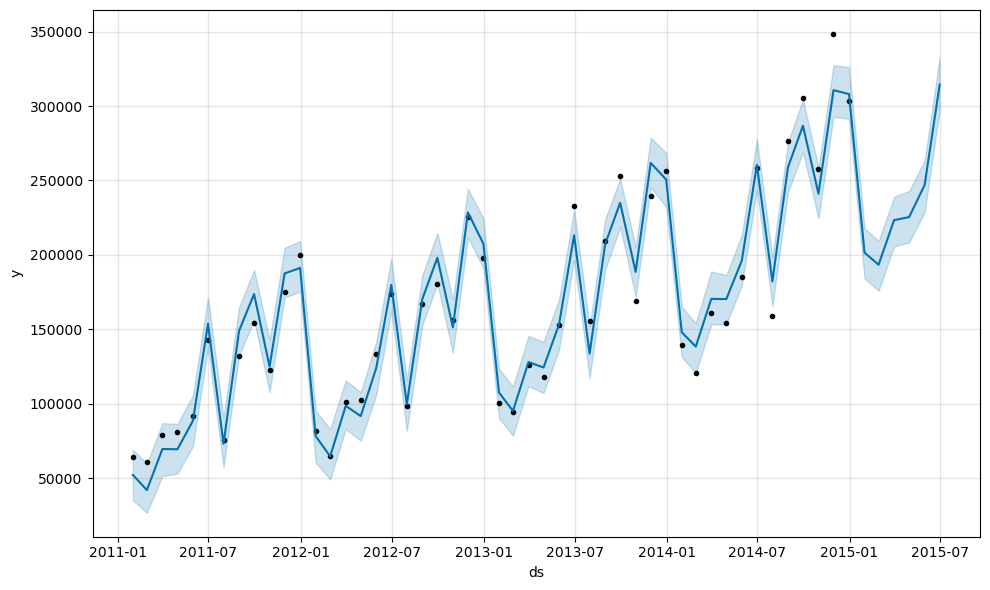

In [20]:
fig = model.plot(forecast)

## Analyze Forecast Components
Break down the forecast into trend and seasonality components.

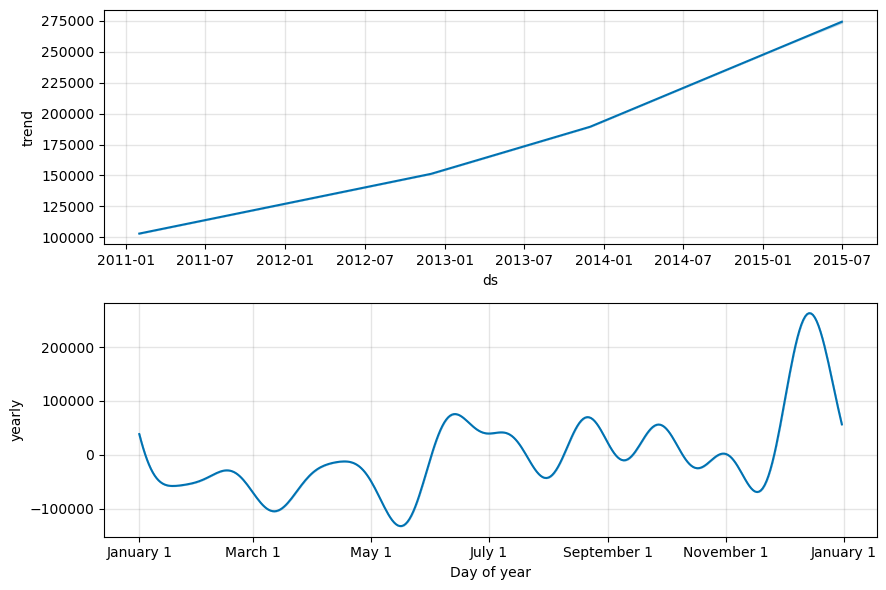

In [21]:
fig2 = model.plot_components(forecast)

### Preparing Data for Actual vs Forecast Comparison

Historical sales and forecasted values were combined into a single dataset to enable direct comparison in Power BI. The datasets were aligned on a common date field and merged using an outer join, ensuring both past actuals and future forecast periods were included.

## Load Time Series Dataset
Load the monthly time series dataset to access actual sales values.

In [24]:
monthly_sales = pd.read_csv("D:/Projects/super-store-orders-forecasting/03_analysis_output/monthly_sales_timeseries.csv")
monthly_sales["order_date"] = pd.to_datetime(monthly_sales["order_date"])

monthly_sales.head()

,order_date,total_sales,total_profit,rolling_sales_3mo,rolling_profit_3mo
0,2011-01-31,64363.0,3857.14052,NaN,NaN
1,2011-02-28,60848.0,5126.20778,NaN,NaN
2,2011-03-31,78983.0,7394.58030,68064.666667,5459.309533
3,2011-04-30,80698.0,6719.46738,73509.666667,6413.418487
4,2011-05-31,91536.0,5133.88400,83739.000000,6415.977227


In [37]:
actual_chart = monthly_sales[["order_date", "total_sales"]].rename(columns={
    "total_sales": "actual_sales"
})

forecast_chart = forecast[["ds", "yhat"]].rename(columns={
    "ds": "order_date",
    "yhat": "forecast_sales"
})

forecast_chart["order_date"] = pd.to_datetime(forecast_chart["order_date"])

chart_data = actual_chart.merge(
    forecast_chart,
    on="order_date",
    how="outer"
).sort_values("order_date")

chart_data.head()
chart_data.tail()

,order_date,actual_sales,forecast_sales
49,2015-02-28,NaN,193345.072445
50,2015-03-31,NaN,223309.195602
51,2015-04-30,NaN,225375.036987
52,2015-05-31,NaN,246944.044052
53,2015-06-30,NaN,314364.205900


This structure simplifies dashboard design by allowing both metrics to be plotted on the same time axis without requiring multiple data sources or complex relationships.

## Export Forecast Results
Save the forecast output for dashboard development and further analysis.

In [36]:
chart_data.to_csv("D:/Projects/super-store-orders-forecasting/03_analysis_output/actual_vs_forecast_chart_data.csv", index=False)